# Evaluasi FEM 3 Kelas dengan FER2013

## Import Library

In [2]:

from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Konfigurasi Mapping Label 7 Kelas ke 3 Kelas

FER2013 asli:
- 0 = angry
- 1 = disgust
- 2 = fear
- 3 = happy
- 4 = sad
- 5 = surprise
- 6 = neutral

Mapping:
- `happy -> positive`
- `neutral -> neutral`
- lainnya -> `negative`


In [3]:

FER_LABEL_MAP = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

MAP_7_TO_3 = {
    "happy": "positive",
    "neutral": "neutral",
    "angry": "negative",
    "disgust": "negative",
    "fear": "negative",
    "sad": "negative",
    "surprise": "negative"
}

LABELS_3 = ["negative", "neutral", "positive"]


## Import Dataset FER2013

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Path to dataset files: /home/fadawkas/.cache/kagglehub/datasets/msambare/fer2013/versions/1


## Load Dataset dan Pembentukan Data Evaluasi

In [5]:
from pathlib import Path

# Pakai `path` dari sel kagglehub di atas; kalau belum dijalankan, unduh otomatis.
try:
    fer_root = Path(path)
except NameError:
    import kagglehub
    fer_root = Path(kagglehub.dataset_download("msambare/fer2013"))


def _find_pixel_csv(root: Path):
    for p in sorted(root.rglob("*.csv")):
        try:
            head = pd.read_csv(p, nrows=1)
        except Exception:
            continue
        if "emotion" in head.columns and "pixels" in head.columns:
            return p
    return None


csv_path = _find_pixel_csv(fer_root)
test_img_root = fer_root / "test"
known_7 = set(FER_LABEL_MAP.values())

if csv_path is not None:
    df = pd.read_csv(csv_path)
    print("(mode) CSV dengan kolom emotion + pixels:", csv_path)
    print(df.head())
    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    if "Usage" in df.columns:
        test_df = df[df["Usage"].isin(["PublicTest", "PrivateTest"])].copy()
    else:
        test_df = df.copy()
    test_df["emotion_name"] = test_df["emotion"].map(FER_LABEL_MAP)
elif test_img_root.is_dir() and any((test_img_root / e).is_dir() for e in known_7):
    name_to_idx = {v: k for k, v in FER_LABEL_MAP.items()}
    rows = []
    for emotion_name in sorted(known_7):
        emo_dir = test_img_root / emotion_name
        if not emo_dir.is_dir():
            continue
        paths = sorted(emo_dir.glob("*.jpg")) + sorted(emo_dir.glob("*.jpeg")) + sorted(emo_dir.glob("*.png"))
        for img_path in paths:
            rows.append({
                "image_path": str(img_path),
                "emotion": name_to_idx[emotion_name],
                "emotion_name": emotion_name,
            })
    df = pd.DataFrame(rows)
    test_df = df.copy()
    print("(mode) Folder gambar: test/<emotion>/* (mis. msambare/fer2013 di kagglehub)")
    print(df.head())
    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())
else:
    raise FileNotFoundError(
        f"Tidak menemukan CSV FER (kolom emotion+pixels) atau folder test/<7 emosi> di {fer_root}"
    )

if "emotion_name" not in test_df.columns:
    test_df["emotion_name"] = test_df["emotion"].map(FER_LABEL_MAP)

print("\nTest/eval shape:", test_df.shape)
test_df["label_3"] = test_df["emotion_name"].map(MAP_7_TO_3)

print("\nDistribusi label 3 kelas:")
print(test_df["label_3"].value_counts())


(mode) Folder gambar: test/<emotion>/* (mis. msambare/fer2013 di kagglehub)
                                          image_path  emotion emotion_name
0  /home/fadawkas/.cache/kagglehub/datasets/msamb...        0        angry
1  /home/fadawkas/.cache/kagglehub/datasets/msamb...        0        angry
2  /home/fadawkas/.cache/kagglehub/datasets/msamb...        0        angry
3  /home/fadawkas/.cache/kagglehub/datasets/msamb...        0        angry
4  /home/fadawkas/.cache/kagglehub/datasets/msamb...        0        angry

Shape: (7178, 3)

Columns: ['image_path', 'emotion', 'emotion_name']

Test/eval shape: (7178, 3)

Distribusi label 3 kelas:
label_3
negative    4171
positive    1774
neutral     1233
Name: count, dtype: int64


## Konversi Data FER2013 Menjadi Citra untuk Visualisasi

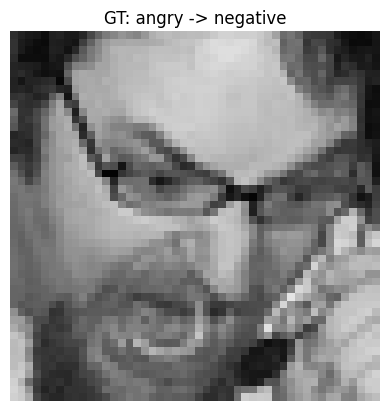

In [6]:

def fer_pixels_to_pil(pixel_string: str) -> Image.Image:
    pixels = np.array([int(p) for p in pixel_string.split()], dtype=np.uint8)
    img = pixels.reshape(48, 48)
    return Image.fromarray(img).convert("RGB")


def fer_row_to_pil(row) -> Image.Image:
    if "pixels" in row.index and pd.notna(row["pixels"]):
        return fer_pixels_to_pil(str(row["pixels"]))
    return Image.open(row["image_path"]).convert("RGB")


# contoh visualisasi
sample_img = fer_row_to_pil(test_df.iloc[0])
plt.imshow(sample_img)
plt.axis("off")
plt.title(f'GT: {test_df.iloc[0]["emotion_name"]} -> {test_df.iloc[0]["label_3"]}')
plt.show()


## Load Model FEM

In [11]:

clf = pipeline(
    "image-classification",
    model="dima806/facial_emotions_image_detection",
    device=-1  # ganti 0 jika pakai GPU
)

# test cepat
pred_example = clf(sample_img)
pred_example[:3]


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[{'label': 'angry', 'score': 0.9850223660469055},
 {'label': 'sad', 'score': 0.004524780437350273},
 {'label': 'fear', 'score': 0.003926169592887163}]

## Jalankan Evaluasi

In [12]:
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

MAX_SAMPLES = min(len(test_df), 5000)
y_true = []
y_pred = []
rows = []

for i in range(MAX_SAMPLES):
    row = test_df.iloc[i]

    img = fer_row_to_pil(row)
    gt_7 = row["emotion_name"]
    gt_3 = row["label_3"]

    pred = clf(img)[0]
    pred_7 = pred["label"].lower()
    pred_score = float(pred["score"])
    pred_3 = MAP_7_TO_3.get(pred_7, "negative")

    y_true.append(gt_3)
    y_pred.append(pred_3)

    rows.append({
        "index": i,
        "gt_7": gt_7,
        "gt_3": gt_3,
        "pred_7": pred_7,
        "pred_3": pred_3,
        "score": pred_score
    })

result_df = pd.DataFrame(rows)
result_df.head()


,index,gt_7,gt_3,pred_7,pred_3,score
0,0,happy,positive,fear,negative,0.549294
1,1,happy,positive,happy,positive,0.963933
2,2,happy,positive,happy,positive,0.932702
3,3,happy,positive,angry,negative,0.706146
4,4,neutral,neutral,neutral,neutral,0.961130


## Hitung Metrik Evaluasi

In [13]:

acc = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print("=== HASIL EVALUASI FEM 3 KELAS ===")
print(f"Jumlah sampel       : {len(y_true)}")
print(f"Accuracy            : {acc:.4f}")
print(f"Precision Macro     : {precision_macro:.4f}")
print(f"Recall Macro        : {recall_macro:.4f}")
print(f"F1-score Macro      : {f1_macro:.4f}")
print(f"Precision Weighted  : {precision_weighted:.4f}")
print(f"Recall Weighted     : {recall_weighted:.4f}")
print(f"F1-score Weighted   : {f1_weighted:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=LABELS_3, zero_division=0))


=== HASIL EVALUASI FEM 3 KELAS ===
Jumlah sampel       : 5000
Accuracy            : 0.9338
Precision Macro     : 0.9221
Recall Macro        : 0.9174
F1-score Macro      : 0.9197
Precision Weighted  : 0.9340
Recall Weighted     : 0.9338
F1-score Weighted   : 0.9338

Classification Report:

              precision    recall  f1-score   support

    negative       0.95      0.96      0.95      2880
     neutral       0.86      0.87      0.86       898
    positive       0.96      0.93      0.94      1222

    accuracy                           0.93      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.93      0.93      0.93      5000



## Confusion Matrix

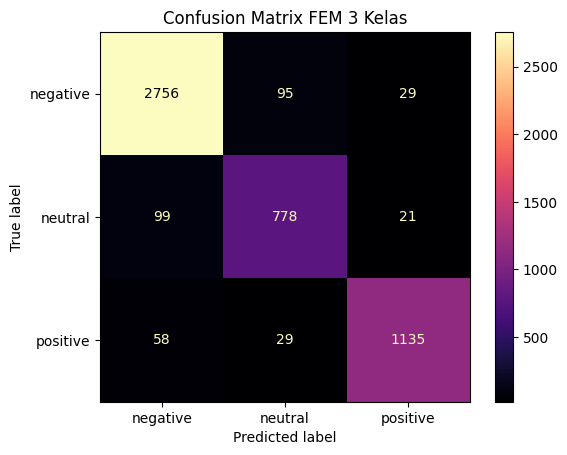

,pred_negative,pred_neutral,pred_positive
true_negative,2756,95,29
true_neutral,99,778,21
true_positive,58,29,1135


In [14]:

cm = confusion_matrix(y_true, y_pred, labels=LABELS_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS_3)
disp.plot(cmap="magma")
plt.title("Confusion Matrix FEM 3 Kelas")
plt.show()

cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in LABELS_3], columns=[f"pred_{x}" for x in LABELS_3])
cm_df


## Simpan Hasil Evaluasi

In [ ]:

result_df.to_csv("hasil_prediksi_fem_3kelas.csv", index=False)

summary_df = pd.DataFrame([{
    "samples": len(y_true),
    "accuracy": acc,
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted,
    "f1_weighted": f1_weighted
}])

summary_df.to_csv("ringkasan_evaluasi_fem_3kelas.csv", index=False)

print("Saved:")
print("- hasil_prediksi_fem_3kelas.csv")
print("- ringkasan_evaluasi_fem_3kelas.csv")


Saved:
- hasil_prediksi_fem_3kelas.csv
- ringkasan_evaluasi_fem_3kelas.csv


## Analisis Error per Kelas

In [ ]:

misclassified = result_df[result_df["gt_3"] != result_df["pred_3"]].copy()
print("Jumlah salah klasifikasi:", len(misclassified))
misclassified.head(20)


Jumlah salah klasifikasi: 340


,index,gt_7,gt_3,pred_7,pred_3,score
44,44,neutral,neutral,sad,negative,0.420173
65,65,happy,positive,neutral,neutral,0.526719
96,96,neutral,neutral,angry,negative,0.486978
101,101,neutral,neutral,sad,negative,0.797855
109,109,happy,positive,sad,negative,0.832400
112,112,happy,positive,neutral,neutral,0.527169
140,140,fear,negative,neutral,neutral,0.456783
172,172,neutral,neutral,fear,negative,0.968126
176,176,happy,positive,disgust,negative,0.972417
240,240,sad,negative,neutral,neutral,0.443371
